This appendix contains all Python code used for data processing, analysis, and visualization in support of the research article "Health Care Utilization and Immigration Enforcement."

# Environment Setup

Import required libraries.

In [67]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.colors import LogNorm
warnings.filterwarnings('ignore')
import pandas as pd
import geopandas as gpd
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time
from pathlib import Path
import zipcodes
from scipy import stats
import os
import janitor 
import matplotlib.ticker as mtick
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json

# Data Loading

Load the datasets for analysis.

## CDC PLACES: Routine checkup within the past year among adults (outcome, 2018-2023)

This data is available from CDC's PLACES data and provides information on the percentage of adults who reported having a routine checkup within the past year, broken down by county, zip, census tract, and year from 2020-2025 (data years from 2018-2023). This dataset will serve as our primary outcome variable, allowing us to assess health care utilization patterns in relation to local enforcement intensity.

Load PLACES: Local Data for Better Health:

- 2025 releases (2023 data):
    - [Census Tract Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-Census-Tract-D/cwsq-ngmh/about_data)

    - [County Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/swc5-untb/about_data)

    - [ZCTA Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-ZCTA-Data-2025/qnzd-25i4/about_data)

- 2024 releases (2022 data):
    - [Census Tract Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-Census-Tract-D/ai6z-tcin/about_data)

    - [County Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/fu4u-a9bh/about_data)

    - [ZCTA Data](https://catalog.data.gov/dataset/places-local-data-for-better-health-zcta-data-2024-release)

- 2023 releases (2021 data):
    - [Census Tract Data](https://data.cdc.gov/d/em5e-5hvn)

    - [County Data](https://data.cdc.gov/d/h3ej-a9ec)

    - [ZCTA Data](https://data.cdc.gov/d/9umn-c3jf)

- 2022 releases (2020 data):
    - [Census Tract Data](https://data.cdc.gov/d/nw2y-v4gm)

    - [County Data](https://data.cdc.gov/d/duw2-7jbt)

    - [ZCTA Data](https://data.cdc.gov/d/gd4x-jyhw)

- 2021 releases (2019 data):
    - [Census Tract Data](https://data.cdc.gov/d/373s-ayzu)

    - [County Data](https://data.cdc.gov/d/pqpp-u99h)

    - [ZCTA Data](https://data.cdc.gov/d/s85h-9xpy)

- 2020 releases (2018 data):
    - [Census Tract Data](https://data.cdc.gov/d/4ai3-zynv)

    - [County Data](https://data.cdc.gov/d/dv4u-3x3q)

    - [ZCTA Data](https://data.cdc.gov/d/fbbf-hgkc)

> Note: Data released each year reflects BRFSS data from 2 years prior. For e.g., 2025 release reflects 2023 BRFSS data. 2016-2019 release data is also available, but data format is not consistent.

> NOTE: try looking for demographic data from PLACES (e.g., race/ethnicity etc.)

In [24]:
# Load CDC PLACES data
# Data source: CDC PLACES
# Time period: 2018-2023
# Geographic levels: County, ZIP code, Census tract

file_templates = {
    "census": "Data/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data_{release}_release.csv",
    "county": "Data/PLACES__Local_Data_for_Better_Health,_County_Data_{release}_release.csv",
    "zip": "Data/PLACES__Local_Data_for_Better_Health,_ZCTA_Data_{release}_release.csv",
}

for release_year in range(2025, 2019, -1):  # 2025, 2024, ..., 2020
    data_year = release_year - 2

    globals()[f"places_census_{data_year}"] = pd.read_csv(
        file_templates["census"].format(release=release_year)
    )
    globals()[f"places_county_{data_year}"] = pd.read_csv(
        file_templates["county"].format(release=release_year)
    )
    globals()[f"places_zip_{data_year}"] = pd.read_csv(
        file_templates["zip"].format(release=release_year)
    )

## Census API: Demographic data (predictors)

Merge on demographics from Census data to zip code level PLACES data.

In [25]:
# Census API: Demographic data (predictors)
CENSUS_KEY = os.getenv("CENSUS_API_KEY")  # set in your environment
ACS_VARS = [
    "NAME",
    # Race / ethnicity / citizenship
    "B02001_001E","B02001_002E","B02001_003E","B02001_004E","B02001_005E","B02001_006E","B02001_007E","B02001_008E",
    "B03003_001E","B03003_003E",
    "B05001_001E","B05001_005E","B05001_006E",
    # Additional SDOH controls
    "B19013_001E",
    "B17001_001E","B17001_002E",
    "B15003_001E","B15003_017E","B15003_018E","B15003_019E","B15003_020E","B15003_021E","B15003_022E","B15003_023E","B15003_024E","B15003_025E",
    "B23025_003E","B23025_005E",
    "B25070_001E","B25070_007E","B25070_008E","B25070_009E","B25070_010E",
    "B28002_001E","B28002_013E",
    "B08201_001E","B08201_002E"
]

# Define function to fetch ACS data for all ZCTAs for a given year
def fetch_acs_zcta(year: int, census_key: str | None = None) -> pd.DataFrame:
    base = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": ",".join(ACS_VARS),
        "for": "zip code tabulation area:*"
    }
    if census_key:
        params["key"] = census_key

    r = requests.get(base, params=params, timeout=120)
    r.raise_for_status()
    rows = r.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])

    # Standardized merge key
    df["zcta5"] = df["zip code tabulation area"].astype(str).str.zfill(5)
    df["acs_year"] = year

    numeric_cols = [c for c in df.columns if c.endswith("E")]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Friendly names
    df = df.rename(columns={
        "B02001_001E": "race_total",
        "B02001_002E": "white_alone",
        "B02001_003E": "black_alone",
        "B02001_004E": "aian_alone",
        "B02001_005E": "asian_alone",
        "B02001_006E": "nhpi_alone",
        "B02001_007E": "other_race_alone",
        "B02001_008E": "two_plus_races",

        "B03003_001E": "ethnicity_total",
        "B03003_003E": "hispanic_latino",

        "B05001_001E": "citizenship_total",
        "B05001_005E": "naturalized_citizen",
        "B05001_006E": "non_citizen",

        "B19013_001E": "median_household_income",
        "B17001_001E": "poverty_universe",
        "B17001_002E": "below_poverty",

        "B15003_001E": "education_25plus",
        "B15003_017E": "hs_grad",
        "B15003_018E": "ged",
        "B15003_019E": "some_college_lt1yr",
        "B15003_020E": "some_college_no_degree",
        "B15003_021E": "associate_degree",
        "B15003_022E": "bachelors",
        "B15003_023E": "masters",
        "B15003_024E": "professional_school",
        "B15003_025E": "doctorate",

        "B23025_003E": "labor_force",
        "B23025_005E": "unemployed",

        "B25070_001E": "renter_occupied",
        "B25070_007E": "rent_30_34pct",
        "B25070_008E": "rent_35_39pct",
        "B25070_009E": "rent_40_49pct",
        "B25070_010E": "rent_50plus_pct",

        "B28002_001E": "households_total",
        "B28002_013E": "no_internet_households",

        "B08201_001E": "households_vehicle",
        "B08201_002E": "no_vehicle_households"
    })

    # Shares (0-1)
    race_den = df["race_total"].replace(0, pd.NA)
    eth_den = df["ethnicity_total"].replace(0, pd.NA)
    cit_den = df["citizenship_total"].replace(0, pd.NA)
    pov_den = df["poverty_universe"].replace(0, pd.NA)
    edu_den = df["education_25plus"].replace(0, pd.NA)
    labor_den = df["labor_force"].replace(0, pd.NA)
    rent_den = df["renter_occupied"].replace(0, pd.NA)
    internet_den = df["households_total"].replace(0, pd.NA)
    vehicle_den = df["households_vehicle"].replace(0, pd.NA)

    df["pct_white"] = df["white_alone"] / race_den
    df["pct_black"] = df["black_alone"] / race_den
    df["pct_asian"] = df["asian_alone"] / race_den
    df["pct_two_plus"] = df["two_plus_races"] / race_den
    df["pct_other_race"] = (df["other_race_alone"] + df["aian_alone"] + df["nhpi_alone"]) / race_den

    df["pct_hispanic_latino"] = df["hispanic_latino"] / eth_den
    df["pct_non_hispanic_latino"] = 1 - df["pct_hispanic_latino"]

    df["pct_naturalized"] = df["naturalized_citizen"] / cit_den
    df["pct_non_citizen"] = df["non_citizen"] / cit_den
    df["pct_citizen"] = 1 - df["pct_non_citizen"]

    df["pct_below_poverty"] = df["below_poverty"] / pov_den
    df["pct_bachelors_plus"] = (
        df["bachelors"] + df["masters"] + df["professional_school"] + df["doctorate"]
    ) / edu_den
    df["pct_high_school_or_higher"] = (
        df["hs_grad"] + df["ged"] + df["some_college_lt1yr"] + df["some_college_no_degree"]
        + df["associate_degree"] + df["bachelors"] + df["masters"] + df["professional_school"] + df["doctorate"]
    ) / edu_den
    df["pct_unemployed"] = df["unemployed"] / labor_den
    df["pct_rent_burdened_30_plus"] = (
        df["rent_30_34pct"] + df["rent_35_39pct"] + df["rent_40_49pct"] + df["rent_50plus_pct"]
    ) / rent_den
    df["pct_no_internet"] = df["no_internet_households"] / internet_den
    df["pct_no_vehicle"] = df["no_vehicle_households"] / vehicle_den

    keep = [
        "zcta5",
        "acs_year",
        "pct_white",
        "pct_black",
        "pct_asian",
        "pct_two_plus",
        "pct_other_race",
        "pct_hispanic_latino",
        "pct_non_hispanic_latino",
        "pct_naturalized",
        "pct_non_citizen",
        "pct_citizen",
        "median_household_income",
        "pct_below_poverty",
        "pct_bachelors_plus",
        "pct_high_school_or_higher",
        "pct_unemployed",
        "pct_rent_burdened_30_plus",
        "pct_no_internet",
        "pct_no_vehicle"
    ]
    return df[keep]

# Years to fetch ACS for (based on PLACES data)
places_data_years = set([2018, 2019, 2020, 2021, 2022, 2023])

# Fetch ACS data for each year
acs_by_year = {}
for year in sorted(places_data_years):
    # Try to fetch.
    try:
        acs_by_year[year] = fetch_acs_zcta(year, CENSUS_KEY)
        print(f"Fetched ACS for {year}: {len(acs_by_year[year]):,} ZCTAs")
        
        # Merge onto each PLACES release file
        places = globals()[f"places_zip_{year}"]
        
        # Standardized merge key
        places["zcta5"] = pd.to_numeric(places["LocationName"], errors="coerce").astype("Int64").astype(str).str.zfill(5)
        places["analysis_year"] = pd.to_numeric(places["Year"], errors="coerce").astype("Int64")

        merged_parts = []
        for y, sub in places.groupby("analysis_year", dropna=True):
            y = int(y)
            if y in acs_by_year:
                merged_parts.append(sub.merge(acs_by_year[y], on="zcta5", how="left"))
            else:
                merged_parts.append(sub)

        # Save as df
        merged = pd.concat(merged_parts, ignore_index=True)
        print(f"Merged places_zip_{year}: {len(merged):,} rows")
        globals()[f"places_zip_{year}_demos"] = merged
        
    # If fetch fails, skip and print error.
    except Exception as e:
        print(f"Skipping {y}: {e}")
    

Fetched ACS for 2018: 33,120 ZCTAs
Merged places_zip_2018: 32,409 rows
Fetched ACS for 2019: 33,120 ZCTAs
Merged places_zip_2019: 31,634 rows
Fetched ACS for 2020: 33,120 ZCTAs
Merged places_zip_2020: 32,409 rows
Fetched ACS for 2021: 33,774 ZCTAs
Merged places_zip_2021: 31,435 rows
Fetched ACS for 2022: 33,774 ZCTAs
Merged places_zip_2022: 27,634 rows
Fetched ACS for 2023: 33,772 ZCTAs
Merged places_zip_2023: 29,983 rows


## TRAC: Detention Facilities Average Daily Population (predictor, 2019-2026)

Load average daily population data from ICE detention facilities. This data is at the zip level.

In [26]:
# Load TRAC detention facilities data
# Data source: TRAC (Transactional Records Access Clearinghouse), retrieved 3/19/2026
# Time period: September 30, 2019 - February 5, 2026

detention_facilities = pd.read_excel('Data/TRAC_DetentionFacilitiesAverageDailyPopulation.xlsx', skiprows=1)

detention_facilities.head()

,Name,City,State,Zip,Type Detailed*,Current Guaranteed Minimum,Average Daily Population,Current as of**
0,Total,NaN,NaN,NaN,NaN,44714,67141.0,2026-02-05
1,ADAMS COUNTY CORRECTIONAL CENTER,NATCHEZ,MS,39120.0,DIGSA,1436,2191.0,2026-02-05
2,ADELANTO ICE PROCESSING CENTER,ADELANTO,CA,92301.0,CDF,640,1802.0,2026-02-05
3,ALEXANDRIA STAGING FACILI,ALEXANDRIA,LA,71303.0,STAGING,NaN,410.0,2026-02-05
4,ALLEGANY COUNTY JAIL,BELMONT,NY,14813.0,USMS IGA,NaN,6.0,2026-02-05


## TRAC: ICE Detention Demographic Data (2015-2019)

We scrape Immigration and Customs Enforcement Detention data (source: https://tracreports.org/phptools/immigration/detention/) and load monthly counts of individuals detained by ICE at the county level with demographic breakdowns.

In [27]:
# Define function to scrape data from TRAC website for all dropdown metrics (citizenship, gender, etc.) across all states and counties for a particular month and year.
def scrape_all_trac_metrics(period="1907"):
    print("Initializing API connection...")
    
    session = requests.Session()
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': 'text/html, */*; q=0.01',
        'X-Requested-With': 'XMLHttpRequest',
        'Referer': 'https://tracreports.org/phptools/immigration/detention/'
    }
    session.headers.update(headers)
    
    # Initial connection
    session.get('https://tracreports.org/phptools/immigration/detention/')
    api_base = "https://tracreports.org/phptools/immigration/detention/table.php"
    period = str(period)  # e.g., "1907" for July 2019
    print(f"Connected to TRAC API. Starting data extraction for period {period}...")
    
    # The list of all dropdown metrics from the TRAC website
    metrics_to_scrape = {
        "facility_type": "Facility Type",
        "type_detailed": "Facility Type (Detailed)",
        "facility_operator": "Facility Operator",
        "facility_owner": "Facility Owner",
        "fymon": "Entered ICE Custody by Month",
        "entry_grp_display": "Time in U.S.",
        "permanent_resident": "Legal Permanent Resident",
        "asylum_sought": "Asylum Seeker/Refugee",
        "most_ser_crim_conv": "Most Serious Criminal Conviction",
        "mscc_grp": "Seriousness Level of MSCC",
        "time_since_conv_disp": "Length of Time Since MSCC",
        "gender": "Gender",
        "citizenship": "Citizenship",
        "age_grp": "Age Group"
    }
    
    master_data = []

    # 1. Get ALL States
    print("Fetching State list...")
    state_url = f"{api_base}?stat=count&period={period}&dimension=state&sort=valdesc"
    state_resp = session.get(state_url)
    state_soup = BeautifulSoup(state_resp.text, 'html.parser')
    
    state_dict = {}
    for row in state_soup.select("tbody tr"):
        link = row.find('a')
        if link and "tableClick" in link.get('href', ''):
            state_name = link.text.strip()
            if state_name == "All":
                continue
            state_id = link['href'].split("'")[3]
            state_dict[state_name] = state_id

    print(f"Found {len(state_dict)} states. Beginning massive extraction...")

    # 2. Loop through ALL States
    for state_name, state_id in state_dict.items():
        print(f"\n--- Processing {state_name} ---")
        
        county_url = f"{api_base}?stat=count&period={period}&state={state_id}&dimension=county&sort=valdesc"
        county_resp = session.get(county_url)
        county_soup = BeautifulSoup(county_resp.text, 'html.parser')
        
        county_dict = {}
        for row in county_soup.select("tbody tr"):
            link = row.find('a')
            if link and "tableClick" in link.get('href', ''):
                county_name = link.text.strip()
                if county_name == "All":
                    continue
                county_id = link['href'].split("'")[3]
                county_dict[county_name] = county_id
                
        # 3. Loop through Counties
        for county_name, county_id in county_dict.items():
            
            # 4. Loop through every metric in our dictionary
            for metric_code, metric_name in metrics_to_scrape.items():
                
                metric_url = (
                    f"{api_base}?stat=count&period={period}&state={state_id}"
                    f"&county={county_id}&dimension={metric_code}&sort=valdesc"
                )
                
                try:
                    metric_resp = session.get(metric_url)
                    metric_soup = BeautifulSoup(metric_resp.text, 'html.parser')
                    
                    # Parse the resulting table
                    for row in metric_soup.select("tbody tr"):
                        cells = row.find_all('td')
                        
                        if len(cells) > 1:
                            category_name = cells[0].text.strip()
                            count_text = cells[1].text.replace(',', '').strip()
                            count = int(count_text) if count_text.isdigit() else 0
                            
                            master_data.append({
                                "State": state_name,
                                "County": county_name,
                                "Metric": metric_name,
                                "Category": category_name,
                                "Count": count
                            })
                            
                except Exception as e:
                    print(f"Error fetching {metric_name} for {county_name}: {e}")
                
                # Polite delay to prevent server overload
                time.sleep(0.1)

            print(f"Finished pulling all metrics for {county_name}")

    return pd.DataFrame(master_data)

In [28]:
# Call function to load data to df for multiple time snapshots.
# List periods
periods = ["1907", "1906", "1905", "1904", "1812", "1811", "1807", "1806", "1803", "1802"]

# Store each period's DataFrame in a dictionary
trac_county_metrics_by_period = {}

for period in periods:
    trac_file_path = Path(f"Data/TRAC_ICE_detention_all_metrics_{period}.csv")

    if trac_file_path.exists():
        trac_df = pd.read_csv(trac_file_path)
    else:
        trac_df = scrape_all_trac_metrics(period=period)
        trac_df.to_csv(trac_file_path, index=False)

    trac_county_metrics_by_period[period] = trac_df
    globals()[f"trac_county_metrics_df_{period}"] = trac_df  # optional convenience

# Combined dataset across periods
trac_county_metrics_df = pd.concat(
    [df.assign(period=period) for period, df in trac_county_metrics_by_period.items()],
    ignore_index=True
)

# Preview
trac_county_metrics_df.head()

,State,County,Metric,Category,Count,period
0,Texas,"Frio County, TX",Facility Type,All,3037,1907
1,Texas,"Frio County, TX",Facility Type,Other Facility Type,3037,1907
2,Texas,"Frio County, TX",Facility Type (Detailed),All,3037,1907
3,Texas,"Frio County, TX",Facility Type (Detailed),Contract Detention Facility: owned by private ...,1996,1907
4,Texas,"Frio County, TX",Facility Type (Detailed),Family: a facility in which families are detai...,1041,1907


# Data Cleaning and Preprocessing

Clean, standardize, and prepare datasets for analysis.

## PLACES

### ZCTA-Level Data

Focusing on the data by ZCTA, we append data across years, handle missings, and fix data types. Only crude prevalence is available at the ZCTA level (not age-adjusted prevalence).

In [29]:
# Data cleaning steps:
# 1. Handle missing values
# 2. Standardize geographic identifiers (county FIPS codes, ZIP codes)
# 3. Convert date formats
# 4. Remove duplicates
# 5. Validate data quality

# Append places_zip_2018 - 2023
places_zip_all_years = pd.concat(
    [globals()[f"places_zip_{year}_demos"] for year in range(2018, 2024)],
    ignore_index=True
)

# Standardize column names and remove empty columns
places_zip_all_years = places_zip_all_years.clean_names().remove_empty()

# ZCTA5 codes should be zero-padded 5-digit strings
places_zip_all_years['zcta5'] = (
    places_zip_all_years['locationname']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Fix column data types
places_zip_all_years['totalpopulation'] = pd.to_numeric(
    places_zip_all_years['totalpopulation']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Drop the original locationname and locationid columns since we have the standardized zip code
places_zip_all_years = places_zip_all_years.drop(columns=['locationname'])
places_zip_all_years = places_zip_all_years.drop(columns=['locationid'])

# Add state and county from ZIP code, remove "County" suffix. NEED to update to use ZCTA5 instead of zip code since that's the standardized key we created.
# county_lookup = {}
# stateabbr_lookup = {}
# for zip_code in places_zip_all_years['ZCTA5'].dropna().unique():
#     matches = zipcodes.matching(str(zip_code))
#     if matches:
#         county = matches[0].get('county')
#         stateabbr = matches[0].get('state')
#         if county:
#             county_lookup[str(zip_code)] = county
#         if stateabbr:
#             stateabbr_lookup[str(zip_code)] = stateabbr
# places_zip_all_years['county'] = places_zip_all_years['ZCTA5'].map(county_lookup).str.replace(' County', '', regex=False)
# places_zip_all_years['stateabbr'] = places_zip_all_years['ZCTA5'].map(stateabbr_lookup)

# Rename data_value to more descriptive name
places_zip_all_years = places_zip_all_years.rename(columns={'data_value': 'doctor_visits_past_year'})

# Drop measure name
places_zip_all_years = places_zip_all_years.drop(columns=['measure'])

# Since totalpop18plus has significant missing values, we will drop it for now
places_zip_all_years = places_zip_all_years.drop(columns=['totalpop18plus'])

# Remove columns that have the same value for all rows--these are not useful for modeling
for col in places_zip_all_years.columns:
    if places_zip_all_years[col].nunique() == 1:
        places_zip_all_years = places_zip_all_years.drop(columns=[col]) 

# Drop duplicates, if any
places_zip_all_years = places_zip_all_years.drop_duplicates()

# Drop if doctor_visits_past_year is missing
places_zip_all_years = places_zip_all_years.dropna(subset=['doctor_visits_past_year'])
    
places_zip_all_years.info()

<class 'pandas.DataFrame'>
RangeIndex: 185504 entries, 0 to 185503
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   year                       185504 non-null  int64  
 1   doctor_visits_past_year    185504 non-null  float64
 2   low_confidence_limit       185504 non-null  float64
 3   high_confidence_limit      185504 non-null  float64
 4   totalpopulation            185504 non-null  int64  
 5   geolocation                185504 non-null  str    
 6   zcta5                      185504 non-null  str    
 7   analysis_year              185504 non-null  Int64  
 8   acs_year                   185401 non-null  float64
 9   pct_white                  184805 non-null  object 
 10  pct_black                  184805 non-null  object 
 11  pct_asian                  184805 non-null  object 
 12  pct_two_plus               184805 non-null  object 
 13  pct_other_race             184805 non-nu

token: eyJhdWQiOiI2IiwianRpIjoiM2JiZGU4ZjNmYTRjNDI3NzY5M2IxY2Y3YmIxMTIzZjg5NTRkNTU2YzUwNjIzYjVkNzU1Y2ViMTRjZTJkYmQzOWExNjI3ZTFlY2IyZWRhNjYiLCJpYXQiOjE3NzUyNDU0NzkuMTY4NjM5LCJuYmYiOjE3NzUyNDU0NzkuMTY4NjQyLCJleHAiOjIwOTA4NjQ2NzkuMTY0NTUxLCJzdWIiOiIxMjQ1NjAiLCJzY29wZXMiOltdfQ

In [30]:
places_zip_all_years.head()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zcta5,analysis_year,acs_year,pct_white,...,pct_non_citizen,pct_citizen,median_household_income,pct_below_poverty,pct_bachelors_plus,pct_high_school_or_higher,pct_unemployed,pct_rent_burdened_30_plus,pct_no_internet,pct_no_vehicle
0,2018,80.5,80.2,80.9,16769,POINT (-72.62581515 42.06255509),01001,2018,2018.0,0.924806,...,0.020714,0.979286,62144.0,0.089569,0.324993,0.914791,0.034201,0.50676,0.162946,0.084748
1,2018,75.6,75.1,76.1,29049,POINT (-72.4509085 42.38758794),01002,2018,2018.0,0.757666,...,0.10906,0.89094,55858.0,0.286926,0.670131,0.951649,0.059449,0.579921,0.064291,0.116128
2,2018,70.5,68.3,72.5,10372,POINT (-72.52475918 42.39190728),01003,2018,2018.0,0.743104,...,0.081242,0.918758,2499.0,0.792683,0.152542,0.771186,0.184043,0.3125,0.0,0.0
3,2018,78.1,77.4,78.8,5079,POINT (-72.10611705 42.42009493),01005,2018,2018.0,0.951513,...,0.004208,0.995792,68278.0,0.068674,0.32362,0.961334,0.059283,0.414384,0.145717,0.04505
4,2018,77.5,76.9,78.0,14649,POINT (-72.40031647 42.27869142),01007,2018,2018.0,0.947284,...,0.017706,0.982294,93300.0,0.05278,0.478063,0.947332,0.039884,0.409736,0.075434,0.051142


### Counties

Both the crude prevalence and age-adjusted prevalence of the outcome variable is available at the county level.

In [31]:
# Append places_county_2018 - 2023
places_county_all_years = pd.concat(
    [globals()[f"places_county_{year}"] for year in range(2018, 2024)],
    ignore_index=True
)

# Standardize column names and remove empty columns
places_county_all_years = places_county_all_years.clean_names().remove_empty()

# Fix column data types
places_county_all_years['totalpopulation'] = pd.to_numeric(
    places_county_all_years['totalpopulation']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Geolocation is misspelled for one year as "Geolocatioin". Standardize to "geolocation"
places_county_all_years['geolocation'] = (
    places_county_all_years['geolocation']
    .combine_first(places_county_all_years['geolocatioin'])
)
places_county_all_years = places_county_all_years.drop(columns=['geolocatioin'], errors='ignore')

# Rename data_value to more descriptive name
places_county_all_years = places_county_all_years.rename(columns={'data_value': 'doctor_visits_past_year'})

# Rename locationname to county for clarity
places_county_all_years = places_county_all_years.rename(columns={'locationname': 'county'})

# Rename statedesc to state
places_county_all_years = places_county_all_years.rename(columns={'statedesc': 'state'})

# Drop measure name
places_county_all_years = places_county_all_years.drop(columns=['measure'])

# Since totalpop18plus has significant missing values, we will drop it for now
places_county_all_years = places_county_all_years.drop(columns=['totalpop18plus'])

# Remove columns that have the same value for all rows--these are not useful for modeling
for col in places_county_all_years.columns:
    if places_county_all_years[col].nunique() == 1:
        places_county_all_years = places_county_all_years.drop(columns=[col]) 

# Drop duplicates, if any
places_county_all_years = places_county_all_years.drop_duplicates()

# Drop if doctor_visits_past_year is missing
places_county_all_years = places_county_all_years.dropna(subset=['doctor_visits_past_year'])
    
places_county_all_years.info()


<class 'pandas.DataFrame'>
Index: 37176 entries, 0 to 37177
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     37176 non-null  int64  
 1   stateabbr                37176 non-null  str    
 2   state                    37176 non-null  str    
 3   county                   37164 non-null  str    
 4   data_value_type          37176 non-null  str    
 5   doctor_visits_past_year  37176 non-null  float64
 6   low_confidence_limit     37176 non-null  float64
 7   high_confidence_limit    37176 non-null  float64
 8   totalpopulation          37176 non-null  int64  
 9   latitude                 6284 non-null   float64
 10  datavaluetypeid          37176 non-null  str    
 11  locationid               30890 non-null  float64
 12  geolocation              37164 non-null  str    
dtypes: float64(5), int64(2), str(6)
memory usage: 4.0 MB


In [32]:
places_county_all_years.head()

,year,stateabbr,state,county,data_value_type,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,latitude,datavaluetypeid,locationid,geolocation
0,2018,US,United States,NaN,Crude prevalence,76.7,76.4,76.9,327167434,NaN,CrdPrv,NaN,NaN
1,2018,US,United States,NaN,Age-adjusted prevalence,75.1,74.8,75.4,327167434,NaN,AgeAdjPrv,NaN,NaN
2,2018,AL,Alabama,Autauga,Crude prevalence,78.4,77.5,79.1,55601,32.535020,CrdPrv,NaN,POINT (-86.64301145 32.5350198)
3,2018,AL,Alabama,Autauga,Age-adjusted prevalence,77.0,76.1,77.9,55601,32.535020,AgeAdjPrv,NaN,POINT (-86.64301145 32.5350198)
4,2018,AL,Alabama,Baldwin,Crude prevalence,78.6,77.8,79.3,218022,30.728117,CrdPrv,NaN,POINT (-87.72275422 30.72811673)


## TRAC: Average Daily Population

We standardize columns names, correct data types, and handle missings.

In [33]:
detention_facilities_clean = detention_facilities.copy()

# Use janitor to clean column names
detention_facilities_clean = detention_facilities_clean.clean_names(remove_special=True)

# Drop if zip code is missing (not useful for analysis)
detention_facilities_clean = detention_facilities_clean.dropna(subset=['zip'])

# Update data types. ZIP codes should be zero-padded 5-digit strings
detention_facilities_clean['zip'] = (
    detention_facilities_clean['zip']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Current Guaranteed Minimum has too many missing values and we can use the total population column instead, so we will drop this column
detention_facilities_clean = detention_facilities_clean.drop(columns=['current_guaranteed_minimum'])

# State has 3 missing values, investigate:
print(detention_facilities_clean[detention_facilities_clean['state'].isna()])

# Impute state based on zip code for missing values
detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'state'] = detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'zip'].map({
    '92301': 'CA',
    '33073': 'FL',
    '71342': 'LA',
    '92301': 'CA'
})

# Map ZIP codes to ZCTAs using HHRSA ZIP-to-ZCTA crosswalk
# Load crosswalk
zip_to_zcta = pd.read_excel('Data/ZIP Code to ZCTA Crosswalk.xlsx').clean_names()
# Standardize ZIP code format in crosswalk
zip_to_zcta['zip_code'] = (zip_to_zcta['zip_code'].astype(int).astype(str).str.zfill(5))
# Merge onto detention facilities data
detention_facilities_clean = detention_facilities_clean.merge(zip_to_zcta[['zip_code', 'zcta']], left_on='zip', right_on='zip_code', how='left')
# Rename zcta to zcta5 for consistency with ACS and PLACES data
detention_facilities_clean = detention_facilities_clean.rename(columns={'zcta': 'zcta5'})
# Drop zip_code column from crosswalk merge
detention_facilities_clean = detention_facilities_clean.drop(columns=['zip_code'])
    
# Replace missing ZCTA values with ZIP code as fallback (for any ZIPs that didn't have a match in the crosswalk), change to string
detention_facilities_clean["zcta5"] = (
    pd.to_numeric(detention_facilities_clean["zcta5"], errors="coerce")
    .fillna(pd.to_numeric(detention_facilities_clean["zip"], errors="coerce"))
    .astype("Int64")
    .astype(str)
    .str.zfill(5)
)

# Rename state to stateabbr
detention_facilities_clean = detention_facilities_clean.rename(columns={'state': 'stateabbr'})

# Add year column by extracting from current_as_of column
detention_facilities_clean['year'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.year

# Add month column
detention_facilities_clean['month'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.month

# Add county from ZIP code, remove "County" suffix
# county_lookup = {}
# for zip_code in detention_facilities_clean['zip'].dropna().unique():
#     matches = zipcodes.matching(str(zip_code))
#     if matches:
#         county_name = matches[0].get('county')
#         if county_name:
#             county_lookup[str(zip_code)] = county_name
# detention_facilities_clean['county'] = detention_facilities_clean['zip'].map(county_lookup).str.replace(' County', '', regex=False)

# Keep only relevant columns for analysis
detention_facilities_clean = detention_facilities_clean[['zcta5', 'year', 'name', 'average_daily_population']].sort_values(by=['zcta5', 'name','year']).reset_index(drop=True)

# Collapse data to the zcta5-year level by first taking the average across facility observations in the same year, and then summing the total population across facilities within each ZCTA-year. (to merge with PLACES and ACS data which are at the ZCTA-year level)
detention_facilities_clean = (
    detention_facilities_clean
    .groupby(['zcta5', 'name', 'year'], as_index=False)['average_daily_population']
    .mean()
    .groupby(['zcta5', 'year'], as_index=False)['average_daily_population']
    .sum()
)

# Summarize
print(detention_facilities_clean.info())

                                                name           city state  \
713                                DESERT VIEW ANNEX       ADELANTO   NaN   
895                      BROWARD TRANSITIONAL CENTER  POMPANO BEACH   NaN   
906  CENTRAL LOUISIANA ICE PROCESSING CENTER (CLIPC)           JENA   NaN   
931                                DESERT VIEW ANNEX       ADELANTO   NaN   

       zip type_detailed  average_daily_population current_as_of  
713  92301           CDF                     385.0    2025-12-11  
895  33073           CDF                     674.0    2025-11-28  
906  71342          IGSA                    1135.0    2025-11-28  
931  92301           CDF                     400.0    2025-11-28  
<class 'pandas.DataFrame'>
RangeIndex: 2875 entries, 0 to 2874
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zcta5                     2875 non-null   str    
 1   year          

In [34]:
# Preview
detention_facilities_clean.head()

,zcta5,year,average_daily_population
0,00603,2021,0.0
1,00692,2021,0.0
2,00802,2021,0.0
3,00820,2021,0.0
4,00909,2021,0.0


## TRAC: Demographics

We standardize columns names, correct data types, and handle missings.

In [35]:
# Clean TRAC county metrics data
# Data cleaning steps:
# 1. Handle missing values
# 2. Standardize geographic identifiers (county FIPS codes, ZIP codes)
# 3. Convert date formats
# 4. Remove duplicates
# 5. Validate data quality

# Standardize column names and remove empty columns
trac_county_clean = trac_county_metrics_df.clean_names().remove_empty()

# Use janitor to clean column names
trac_county_clean = trac_county_clean.clean_names(remove_special=True)

# Split county into county and stateabbr using regex
trac_county_clean['stateabbr'] = trac_county_clean['county'].str.extract(r'^(.*),\s*([A-Z]{2})$')[1]
trac_county_clean['county'] = trac_county_clean['county'].str.extract(r'^(.*),\s*([A-Z]{2})$')[0]

# Remove "County" from county names for standardization
trac_county_clean['county'] = trac_county_clean['county'].str.replace(' County', '', regex=False).str.strip()

# Drop if county is unknown or missing (not useful for analysis)
trac_county_clean = trac_county_clean.dropna(subset=['county'])

# Split period into year and month
trac_county_clean['year'] = pd.to_numeric(trac_county_clean['period'].astype(str).str[:2], errors='coerce') + 2000
trac_county_clean['month'] = pd.to_numeric(trac_county_clean['period'].astype(str).str[2:], errors='coerce')

# Drop period
trac_county_clean = trac_county_clean.drop(columns=['period'])

# Drop duplicates
trac_county_clean = trac_county_clean.drop_duplicates()

# NEED to pick a couple of categories and metrics to pivot wider so that each metric and category combination becomes a separate column
# Keep if metric is "Legal Permanent Resident", "Asylum Seeker/Refugee",

# Summarize
print(trac_county_clean.info())

<class 'pandas.DataFrame'>
Index: 176044 entries, 0 to 176217
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   state      176044 non-null  str  
 1   county     176044 non-null  str  
 2   metric     176044 non-null  str  
 3   category   175697 non-null  str  
 4   count      176044 non-null  int64
 5   stateabbr  176044 non-null  str  
 6   year       176044 non-null  int64
 7   month      176044 non-null  int64
dtypes: int64(3), str(5)
memory usage: 12.1 MB
None


In [36]:
trac_county_clean.head()


,state,county,metric,category,count,stateabbr,year,month
0,Texas,Frio,Facility Type,All,3037,TX,2019,7
1,Texas,Frio,Facility Type,Other Facility Type,3037,TX,2019,7
2,Texas,Frio,Facility Type (Detailed),All,3037,TX,2019,7
3,Texas,Frio,Facility Type (Detailed),Contract Detention Facility: owned by private ...,1996,TX,2019,7
4,Texas,Frio,Facility Type (Detailed),Family: a facility in which families are detai...,1041,TX,2019,7


# Metric Definitions

This section provides definitions of all metrics used in the analysis, organized by data source.

## CDC PLACES: Routine Checkup Within the Past Year Among Adults

**Primary Outcome Variable**

### Metric: Routine Doctor Visit Rate
- **Full Name**: Percentage of adults aged 18 and older who reported having a routine checkup within the past year
- **Variable Name** (in cleaned data): `doctor_visits_past_year`
- **Data Type**: Percentage (0-100)
- **What It Measures**: Healthcare utilization rate; the proportion of the adult population that accessed preventive healthcare services through routine medical checkups
- **Geographic Levels**: County, ZIP Code Tabulation Area (ZCTA), and Census Tract
- **Temporal Coverage**: Data years 2018-2023 (released in 2020-2025 respectively)
- **Source**: Behavioral Risk Factor Surveillance System (BRFSS) survey data collected by CDC
- **Frequency**: Annual (one observation per geographic unit per year)
- **Additional Metadata Included**: Total population, state, location identifiers

---
## Census: SDOH data

- pct_white: B02001_002E / B02001_001E
- pct_black: B02001_003E / B02001_001E
- pct_asian: B02001_004E / B02001_001E
- pct_two_plus: B02001_008E / B02001_001E 
- pct_other_race: B02001_007E / B02001_001E 
- pct_hispanic_latino: B03003_003E / B03003_001E
- pct_non_hispanic_latino: B03003_002E / B03003_001E
- pct_naturalized: B05001_005E / B05001_001E
- pct_non_citizen: B05001_006E / B05001_001E
- pct_citizen: 1 - B05001_006E / B05001_001E
- median_household_income: B19013_001E
- pct_below_poverty: B17001_002E / B17001_001E
- pct_bachelors_plus: (B15003_022E + B15003_023E + B15003_024E + B15003_025E) / B15003_001E
- pct_high_school_or_higher:  (B15003_022E + B15003_023E + B15003_024E + B15003_025E + B15003_017E) / B15003_001E
- pct_unemployed: B23025_005E / B23025_003E
- pct_rent_burdened_30_plus: (B25070_007E + B25070_008E + B25070_009E + B25070_010E) / B25070_001E
- pct_no_internet: B28002_013E / B28002_001E
- pct_no_vehicle: B08201_002E / B08201_001E

---

## TRAC Detention Facilities Data (2019-2026)

**Immigration Enforcement Intensity Metrics**

### Metric 1: Average Daily Population (ADP)
- **Full Name**: Average Daily Population at ICE Detention Facilities
- **Variable Name** (in cleaned data): `average_daily_population` (or similar)
- **Data Type**: Count (number of individuals)
- **What It Measures**: The average number of individuals detained on any given day at a specific ICE detention facility; a measure of detention facility utilization and enforcement intensity
- **Geographic Level**: ZIP Code (facility location)
- **Temporal Coverage**: September 30, 2019 - February 5, 2026 (multiple time points)
- **Source**: TRAC (Transactional Records Access Clearinghouse), retrieved March 19, 2026
- **Frequency**: Periodic snapshots (specific dates, not continuous daily data)
- **Additional Metadata Included**: Facility name, state, zip code, current date

### Metric 2: Current Guaranteed Minimum (dropped)
- **Full Name**: Current Guaranteed Minimum Detainee Population
- **Data Type**: Count (number of individuals)
- **What It Measures**: Minimum number of detainees that detention facilities are contractually obligated to maintain
- **Status**: Dropped during data cleaning due to excessive missing values
- **Note**: Not used in final analysis

---

## TRAC ICE Detention Data (2015-2019)

**Immigration Enforcement Demographic and Categorical Metrics**

### Data Structure
- **DataFrame**: `trac_county_metrics_df`
- **Data Format**: Long format with columns: State, County, Metric, Category, Count
- **Data Type**: Count (number of individuals)
- **Geographic Level**: County
- **Temporal Coverage**: March 2015 - July 2019 (monthly granularity)
- **Source**: TRAC (Transactional Records Access Clearinghouse) - scraped from https://tracreports.org/
- **Frequency**: Monthly
- **Data Collection Method**: Web scraping from TRAC dynamic tables with API calls

### Metrics Available

The `trac_county_metrics_df` contains detailed breakdowns of ICE detention by the following dimensions:

#### 1. **Facility Type** (`facility_type`)
   - **What It Measures**: Classification of detention facilities by operational type
   - **Categories**: Various facility types operated by ICE or private contractors
   - **Use Case**: Understanding which types of facilities are used in different regions

#### 2. **Facility Type (Detailed)** (`type_detailed`)
   - **What It Measures**: More granular classification of detention facilities
   - **Categories**: Detailed facility subcategories
   - **Use Case**: More nuanced facility analysis and operational characteristics

#### 3. **Facility Operator** (`facility_operator`)
   - **What It Measures**: Public or private entity operating the facility
   - **Categories**: Government agencies, private contractors
   - **Use Case**: Analyzing public vs. private detention facility prevalence

#### 4. **Facility Owner** (`facility_owner`)
   - **What It Measures**: Entity that owns the detention facility
   - **Categories**: ICE, local/state authorities, private companies
   - **Use Case**: Understanding facility ownership structure and partnerships

#### 5. **Time in U.S.** (`entry_grp_display`)
   - **What It Measures**: Duration of time individuals have spent in the United States before detention
   - **Categories**: Time ranges (e.g., <1 year, 1-5 years, 5+ years, lifetime resident)
   - **Use Case**: Analyzing enforcement targeting patterns relative to immigration history

#### 6. **Entered ICE Custody by Month** (`fymon`)
   - **What It Measures**: Month and fiscal year when individuals entered ICE custody
   - **Categories**: Monthly breakdown (Oct-Sep fiscal year)
   - **Use Case**: Identifying seasonal patterns in enforcement activity

#### 7. **Legal Permanent Resident** (`permanent_resident`)
   - **What It Measures**: Immigration status - whether detainee is a legal permanent resident
   - **Categories**: Yes/No/Unknown
   - **Use Case**: Analyzing how many detained individuals have established legal status

#### 8. **Asylum Seeker/Refugee** (`asylum_sought`)
   - **What It Measures**: Whether individual has sought or been granted asylum/refugee status
   - **Categories**: Yes/No/Unknown
   - **Use Case**: Understanding enforcement impact on vulnerable populations

#### 9. **Most Serious Criminal Conviction** (`most_ser_crim_conv`)
   - **What It Measures**: The most serious criminal conviction on individual's record
   - **Categories**: Specific conviction types by crime category
   - **Use Case**: Analyzing criminal justice involvement of detained individuals

#### 10. **Seriousness Level of MSCC** (`mscc_grp`)
   - **What It Measures**: Categorization of criminal conviction severity
   - **Categories**: No conviction, misdemeanor, felony (various levels)
   - **Use Case**: Aggregate analysis of criminal justice involvement severity

#### 11. **Length of Time Since MSCC** (`time_since_conv_disp`)
   - **What It Measures**: Years elapsed since most serious criminal conviction
   - **Categories**: Time ranges (e.g., <1 year, 1-5 years, 5+ years, no conviction)
   - **Use Case**: Analyzing recency of criminal involvement in detained population

#### 12. **Gender** (`gender`)
   - **What It Measures**: Gender identity of detained individuals
   - **Categories**: Male, Female, Other/Unknown
   - **Use Case**: Demographic analysis and identifying gender disparities in enforcement

#### 13. **Citizenship** (`citizenship`)
   - **What It Measures**: Country of citizenship for detained individuals
   - **Categories**: Country codes/names
   - **Use Case**: Analyzing which nationalities are most affected by enforcement

#### 14. **Age Group** (`age_grp`)
   - **What It Measures**: Age range of detained individuals
   - **Categories**: Age bands (e.g., 18-21, 22-35, 36-50, 51+)
   - **Use Case**: Demographic analysis of enforcement targeting across age groups

### Data Quality Notes
- **Total Records**: Multiple observations per state-county-metric combination across months (Mar 2015 - Jul 2019)
- **Missing Data**: Some categories may have missing values (represented as 0 or NA)
- **Temporal Structure**: Monthly data points allow for time series and seasonal analysis
- **Status**: Data loading code provides foundation for demographic subgroup analysis

---

## Summary of Key Variables

| Data Source | Primary Metric | Unit | Geography | Time Period | Frequency |
|---|---|---|---|---|---|
| CDC PLACES | Routine doctor visit rate | Percentage (%) | County, ZCTA, Census Tract | 2018-2023 | Annual |
| TRAC Detention Facilities | Average daily population | Count | ZIP Code | Sept 2019 - Feb 2026 | Periodic |
| TRAC ICE Detention | Monthly detention counts (by demographics) | Count | County | Mar 2015 - Jul 2019 | Monthly |

---

## Analysis Design Note

The primary analysis leverages the **CDC PLACES routine checkup rate** as the dependent variable (healthcare utilization outcome) and the **TRAC detention facilities average daily population** as the primary independent variable (immigration enforcement intensity), merged at the ZIP code and year level to create a panel dataset for regression analysis. The **TRAC ICE Detention demographic metrics** provide detailed subgroup analysis capabilities to examine differential impacts across citizenship status, legal status, criminal history, and demographic characteristics.

# Panel Data Construction

Merge datasets across geography and time to create panel data for analysis.

First, merge zip-code level CDC PLACES (outcome variable) and TRAC detention facility population (primary independent variable). We will have 1 row per year and ZCTA combination.

In [58]:
# Merge datasets on geographic identifiers (county/ZIP) and time
# Steps:
# 1. Standardize geographic keys across datasets
# 2. Align temporal granularity (monthly/yearly)
# 3. Join datasets 
# 4. Create balanced panel (if needed)

# Join places_zip_all_years with detention_facilities_clean on ZIP code and year
df_merged = pd.merge(
    places_zip_all_years,
    detention_facilities_clean,
    left_on=['zcta5', 'year'],
    right_on=['zcta5', 'year'],
    how='left'  # Use left join to keep only records matching w/ doctor visits data
)

# if you didn't show up in detention_facilities_clean, then we assume you had NO DETAINEEES
df_merged['average_daily_population'] = df_merged['average_daily_population'].fillna(0)

zip_map = pd.read_csv('https://raw.githubusercontent.com/scpike/us-state-county-zip/refs/heads/master/geo-data.csv')

# 2. Standardize zip codes to ensure they are 5-character strings with leading zeros
# This ensures a clean match between 'zip' and 'zipcode'
zip_map['zipcode'] = zip_map['zipcode'].astype(str).str.zfill(5)

# 3. Create mapping dictionaries from the zip_map
# - 'city' maps to 'city'
city_lookup = zip_map.set_index('zipcode')['city'].to_dict()

# 4. Fill null values in the target columns
# This only fills entries where the data is NaN (the ones that didn't exist in detention_facilities_clean)
# df_merged['city'] = df_merged['city'].fillna(df_merged['zcta5'].map(city_lookup))
# 2018, 2019, and 2020 data current as of August 25, 2023; 2021 data current as of July 15, 2024; 2022 data current as of March 10, 2026; 2023 data current as of December 12, 2025.
# df_merged['current_as_of'] = pd.to_datetime(df_merged['current_as_of'], errors='coerce')
# current_as_of_by_year = {
#    2018: pd.Timestamp('2023-08-25'),
#    2019: pd.Timestamp('2023-08-25'),
#    2020: pd.Timestamp('2023-08-25'),
#    2021: pd.Timestamp('2024-07-15'),
#    2022: pd.Timestamp('2026-03-10'),
#    2023: pd.Timestamp('2025-12-12'),
#}
#df_merged['current_as_of'] = df_merged['current_as_of'].fillna(
#    df_merged['year'].map(current_as_of_by_year)
#)
#df_merged['month'] = pd.to_datetime(df_merged['current_as_of']).dt.month

# Get percent of total population in detention facility
df_merged['pct_population_in_detention'] = df_merged['average_daily_population'] / df_merged['totalpopulation'] 


# List of columns that need to be numeric
cols_to_fix = [
    'pct_white', 'pct_black', 'pct_asian', 'pct_two_plus', 'pct_other_race',
    'pct_hispanic_latino', 'pct_naturalized', 'pct_non_citizen', 
    'pct_below_poverty', 'pct_bachelors_plus', 'pct_high_school_or_higher', 
    'pct_unemployed', 'pct_rent_burdened_30_plus', 'pct_no_internet', 'pct_no_vehicle'
]

# Convert columns to numeric, coercing errors to NaN
for col in cols_to_fix:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

print("Data types updated for visualization.")

# Individual column fixes
df_merged['median_household_income'] = df_merged['median_household_income'].clip(lower=0)

# Export df_merged to CSV for reference in report
df_merged.to_csv('Data/panel_data.csv', index=False)


Data types updated for visualization.


# Exploratory Data Analysis

Examine basic statistics, distributions, and patterns in each dataset.

In [ ]:
# Summary statistics and initial exploration
# - Descriptive statistics for each dataset
# - Time series trends
# - Geographic distribution
# - Correlation analysis



Data types updated for visualization.


## Chloropleth maps of ICE & Doctor Visit activity

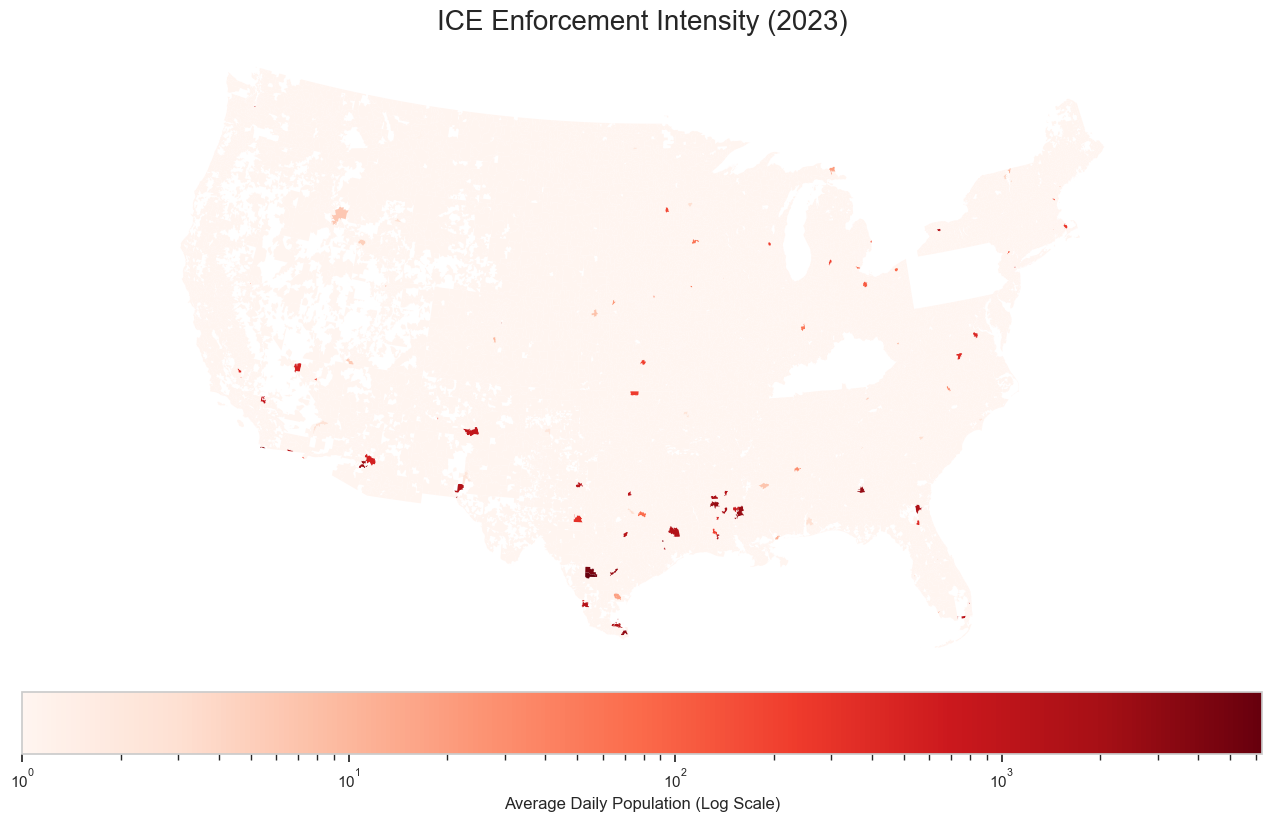

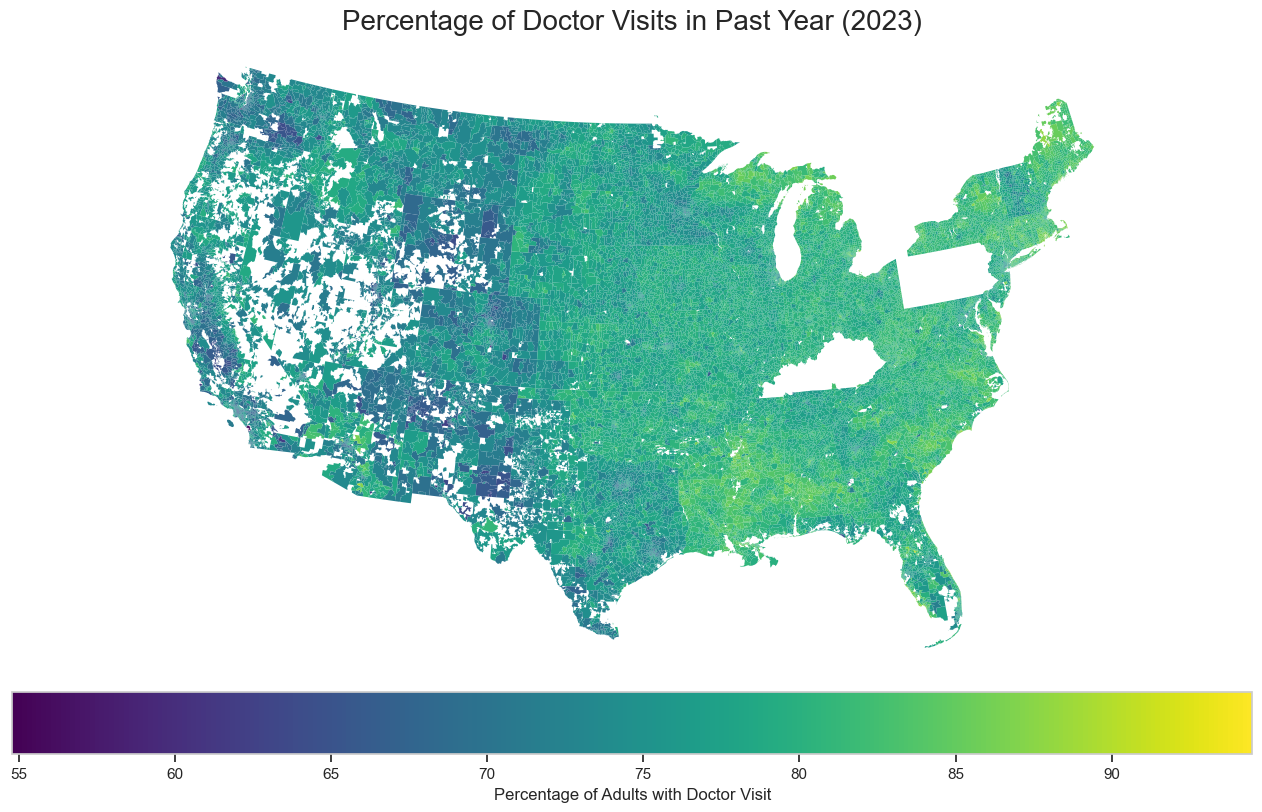

In [ ]:
# 0. Set up Image Directory for Quarto
image_dir = "midterm-images"
os.makedirs(image_dir, exist_ok=True)


# 1. Directory Setup
# Creating the storage path under Data/ dude
h = chr(45)
data_dir = os.path.join("Data", f"zcta{h}spatial")
os.makedirs(data_dir, exist_ok=True)

# 2. Data Filtering
max_year = df_merged['year'].max()
df_plot = df_merged[df_merged['year'] == max_year].copy()

def fetch_usa_geodata(target_dir):
    repo_name = f"State{h}zip{h}code{h}GeoJSON"
    base_url = f"https://raw.githubusercontent.com/OpenDataDE/{repo_name}/master/"
    
    states = [
        "al_alabama", "az_arizona", "ar_arkansas", "ca_california", "co_colorado", 
        "ct_connecticut", "de_delaware", "fl_florida", "ga_georgia", "id_idaho", 
        "il_illinois", "in_indiana", "ia_iowa", "ks_kansas", "ky_kentucky", "la_louisiana", 
        "me_maine", "md_maryland", "ma_massachusetts", "mi_michigan", "mn_minnesota", 
        "ms_mississippi", "mo_missouri", "mt_montana", "ne_nebraska", "nv_nevada", "nh_new_hampshire", 
        "nj_new_jersey", "nm_new_mexico", "ny_new_york", "nc_north_carolina", "nd_north_dakota", 
        "oh_ohio", "ok_oklahoma", "or_oregon", "pa_pennsylvania", "ri_rhode_island", "sc_south_carolina", 
        "sd_south_dakota", "tn_tennessee", "tx_texas", "ut_utah", "vt_vermont", "va_virginia", 
        "wa_washington", "wv_west_virginia", "wi_wisconsin", "wy_wyoming"
    ]
    
    all_features = []
    
    for s in states:
        local_file = os.path.join(target_dir, f"{s}.json")
        
        # Checking if file exists locally before downloading
        if os.path.exists(local_file):
            with open(local_file, "r") as f:
                state_data = json.load(f)
                all_features.extend(state_data["features"])
        else:
            url = f"{base_url}{s}_zip_codes_geo.min.json"
            res = requests.get(url)
            if res.status_code == 200:
                state_json = res.json()
                all_features.extend(state_json["features"])
                # Saving to local directory for next time
                with open(local_file, "w") as f:
                    json.dump(state_json, f)
            
    gdf = gpd.GeoDataFrame.from_features(all_features)
    gdf = gdf.rename(columns={"ZCTA5CE10": "zcta5"})
    return gdf.set_crs("EPSG:4326").to_crs("EPSG:5070")

# 3. Processing
gdf_boundaries = fetch_usa_geodata(data_dir)
gdf_final = gdf_boundaries.merge(df_plot, on="zcta5")

# 4. Figure 1: ICE Enforcement Intensity
gdf_final["ice_plot_val"] = gdf_final["average_daily_population"].fillna(0) + 0.1
vmax_ice = gdf_final["average_daily_population"].max()

plt.figure(figsize=(16, 10))
ax1 = plt.gca()

gdf_final.plot(
    column="ice_plot_val",
    ax=ax1,
    cmap="Reds",
    norm=LogNorm(vmin=1, vmax=vmax_ice),
    legend=True,
    legend_kwds={"label": "Average Daily Population (Log Scale)", "orientation": "horizontal", "pad": 0.02},
    linewidth=0
)

plt.title(f"ICE Enforcement Intensity ({max_year})", fontsize=20)
plt.axis("off")

# SAVE INSTEAD OF SHOW
plt.savefig(os.path.join(image_dir, "map-ice-intensity.png"), dpi=300, bbox_inches="tight")
plt.show()

# 5. Figure 2: Healthcare Access
plt.figure(figsize=(16, 10))
ax2 = plt.gca()

gdf_final.plot(
    column="doctor_visits_past_year",
    ax=ax2,
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Percentage of Adults with Doctor Visit", "orientation": "horizontal", "pad": 0.02},
    linewidth=0
)

plt.title(f"Percentage of Doctor Visits in Past Year ({max_year})", fontsize=20)
plt.axis("off")

# SAVE INSTEAD OF SHOW
plt.savefig(os.path.join(image_dir, "map-doctor-visits.png"), dpi=300, bbox_inches="tight")
plt.show()


## Average Doctor Visits
### Summary Statistics

In [40]:
df_merged[['doctor_visits_past_year']].describe()

,doctor_visits_past_year
count,185504.000000
mean,75.775621
std,4.658043
min,44.600000
25%,73.400000
50%,76.400000
75%,78.900000
max,95.800000


### Distribution of Doctor Visits Across Zipcodes

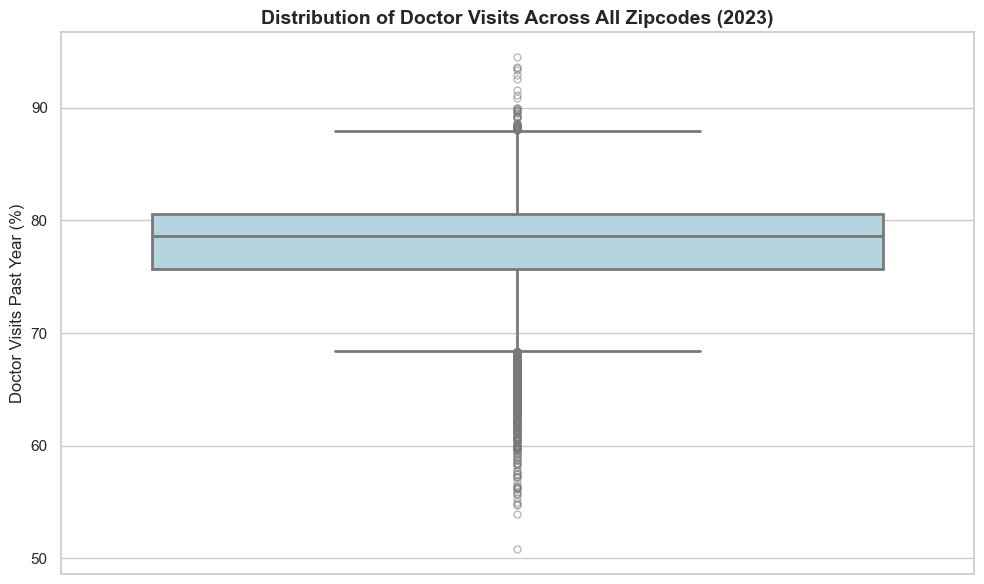

Total ZCTAs: 29983

Doctor Visits Rate Summary:
count    29983.000000
mean        77.833816
std          4.183079
min         50.800000
25%         75.700000
50%         78.600000
75%         80.600000
max         94.500000
Name: doctor_visits_past_year, dtype: float64


In [41]:
# 1. Work directly with places_zip_2023 (latest ZCTA data)
df_zip = places_zip_2023.copy()

# Standardize column names for consistency
df_zip = df_zip.clean_names().remove_empty()

# Rename data_value to doctor_visits_past_year for clarity
df_zip = df_zip.rename(columns={'data_value': 'doctor_visits_past_year'})

# 2. Box and whisker plot of doctor visits distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(
    data=df_zip,
    y='doctor_visits_past_year',
    color='lightblue',
    linewidth=2,
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.5}
)

# Formatting
plt.title('Distribution of Doctor Visits Across All Zipcodes (2023)', fontsize=14, fontweight='bold')
plt.ylabel('Doctor Visits Past Year (%)', fontsize=12)
plt.xlabel('')
plt.xticks([])

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "boxplot-doctor-visits.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3. Summary statistics
print(f"Total ZCTAs: {len(df_zip)}")
print(f"\nDoctor Visits Rate Summary:")
print(df_zip['doctor_visits_past_year'].describe())

### Scatter of Avg daily Detainees and Visits

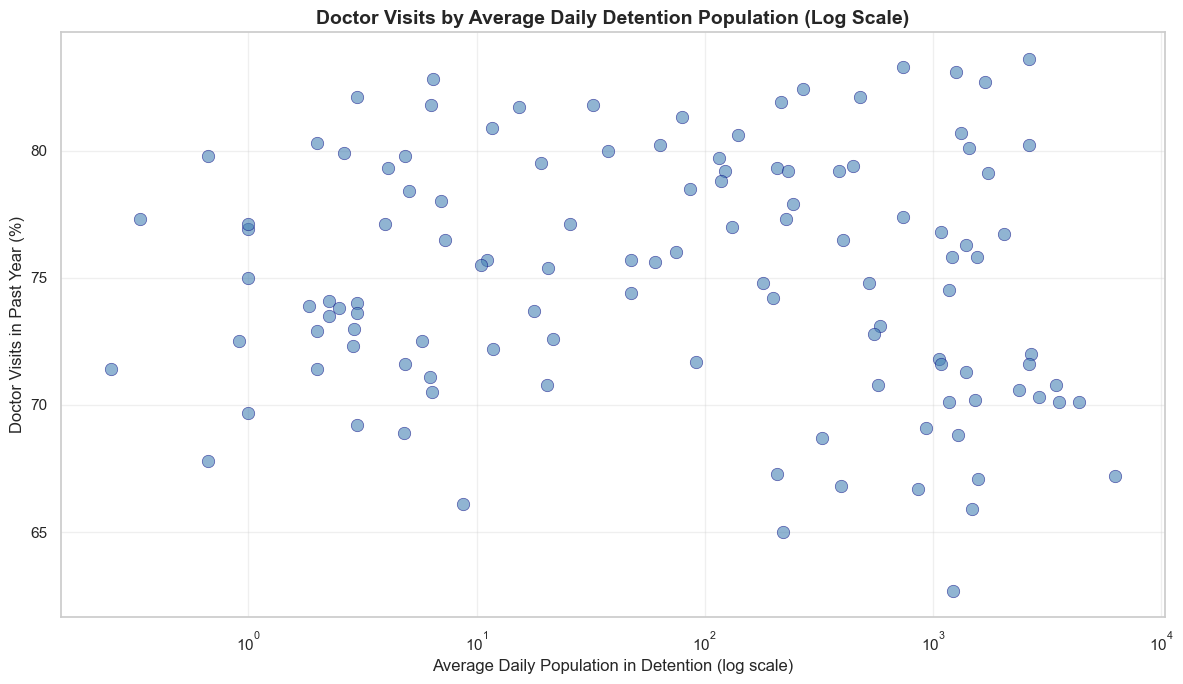

Total observations with detention data: 117

Correlation between doctor visits and detention population:
                          doctor_visits_past_year  average_daily_population
doctor_visits_past_year                  1.000000                 -0.225876
average_daily_population                -0.225876                  1.000000


In [42]:
# Filter for rows with detention data (non-zero and non-null average_daily_population)
df_scatter = df_merged[
    (df_merged['average_daily_population'] > 0) & 
    (df_merged['average_daily_population'].notna()) &
    (df_merged['year'] == df_merged['year'].max())
].copy()

# Create scatter plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_scatter,
    x='average_daily_population',
    y='doctor_visits_past_year',
    alpha=0.6,
    s=80,
    color='steelblue',
    edgecolor='navy',
    linewidth=0.5
)

# Formatting
plt.title('Doctor Visits by Average Daily Detention Population (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Population in Detention (log scale)', fontsize=12)
plt.ylabel('Doctor Visits in Past Year (%)', fontsize=12)

# Apply log scale to x-axis
plt.xscale('log')

# Add grid for readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "scatterplot-drvisits-vs-avg-dly-pop.png"), dpi=300, bbox_inches="tight")
plt.show()

# Summary statistics
print(f"Total observations with detention data: {len(df_scatter)}")
print(f"\nCorrelation between doctor visits and detention population:")
print(f"{df_scatter[['doctor_visits_past_year', 'average_daily_population']].corr()}")

### Doctor Visits by Hispanic Composition 

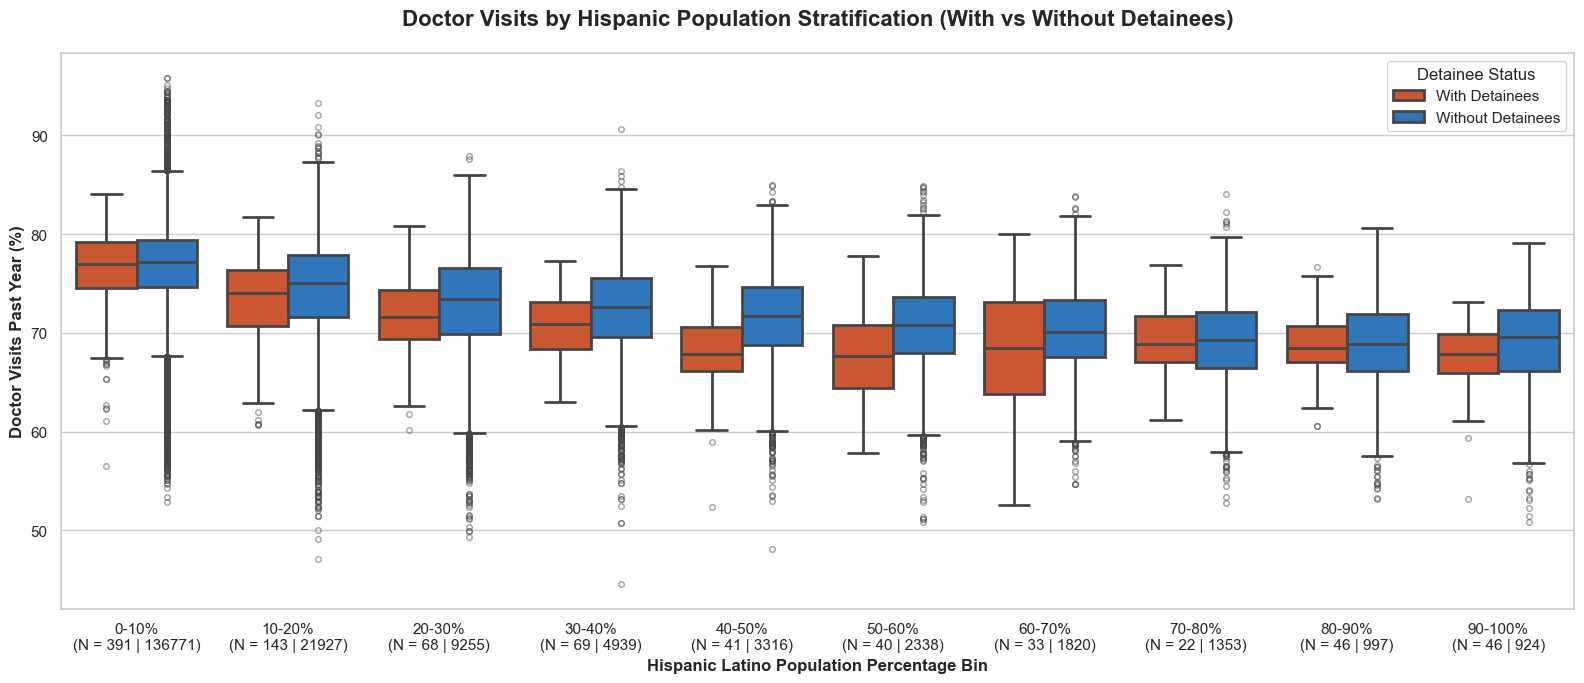

In [43]:
# Create two datasets from df_merged
# 1. With detainees: average_daily_population > 0
df_with_detainees = df_merged[
    (df_merged['average_daily_population'] > 0) & 
    (df_merged['average_daily_population'].notna()) &
    (df_merged['pct_hispanic_latino'].notna())
].copy()

# 2. Without detainees: average_daily_population is 0 or NA
df_without_detainees = df_merged[
    ((df_merged['average_daily_population'].isna()) | 
    (df_merged['average_daily_population'] == 0)) &
    (df_merged['doctor_visits_past_year'].notna()) &
    (df_merged['pct_hispanic_latino'].notna())
].copy()
df_without_detainees['average_daily_population'] = df_without_detainees['average_daily_population'].fillna(0)

# --- NEW: Add an identifier column and combine ---
df_with_detainees['Detainee Status'] = 'With Detainees'
df_without_detainees['Detainee Status'] = 'Without Detainees'
df_combined = pd.concat([df_with_detainees, df_without_detainees], ignore_index=True)

# Function to create combined stratified box plot
def create_combined_boxplot(df):
    # Create hispanic_strata with 10 bins
    df['hispanic_strata'] = pd.cut(
        df['pct_hispanic_latino'],
        bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1],
        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
        right=False
    )
    
    # Set the theme for a clean look
    sns.set_theme(style="whitegrid")
    
    # Define the order for the x-axis categories
    strata_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
    
    # Create a single figure and axis
    plt.figure(figsize=(16, 7))
    
    # Create the grouped boxplot using 'hue' to separate colors
    sns.boxplot(
        data=df,
        x='hispanic_strata',
        y='doctor_visits_past_year',
        hue='Detainee Status',        # Plots datasets side-by-side based on status
        order=strata_labels,          # Ensures categories appear in the correct order
        palette=['#E64A19', '#1976D2'], # Custom colors (e.g., Deep Orange and Blue)
        linewidth=2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )
    
    # Add titles and labels
    plt.title('Doctor Visits by Hispanic Population Stratification (With vs Without Detainees)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Hispanic Latino Population Percentage Bin', fontsize=12, fontweight='bold')
    plt.ylabel('Doctor Visits Past Year (%)', fontsize=12, fontweight='bold')
    
    # Add sample sizes (n=) to the x-tick labels for clarity (Showing both With / Without)
    new_labels = []
    for label in strata_labels:
        n_with = len(df[(df['hispanic_strata'] == label) & (df['Detainee Status'] == 'With Detainees')])
        n_without = len(df[(df['hispanic_strata'] == label) & (df['Detainee Status'] == 'Without Detainees')])
        new_labels.append(f"{label}\n(N = {n_with} | {n_without})")
        
    plt.xticks(ticks=range(len(strata_labels)), labels=new_labels)
    
    # Customize the legend position and title
    plt.legend(title='Detainee Status', loc='upper right')
    
    plt.tight_layout()
    plot_save_title = "boxplot-dr-visits-by-ha-pop-combined.png"
    plt.savefig(os.path.join(image_dir, plot_save_title), dpi=300, bbox_inches="tight")
    plt.show()

# Create the single combined plot
create_combined_boxplot(df_combined)

### Visits by Percentage Citizen Status

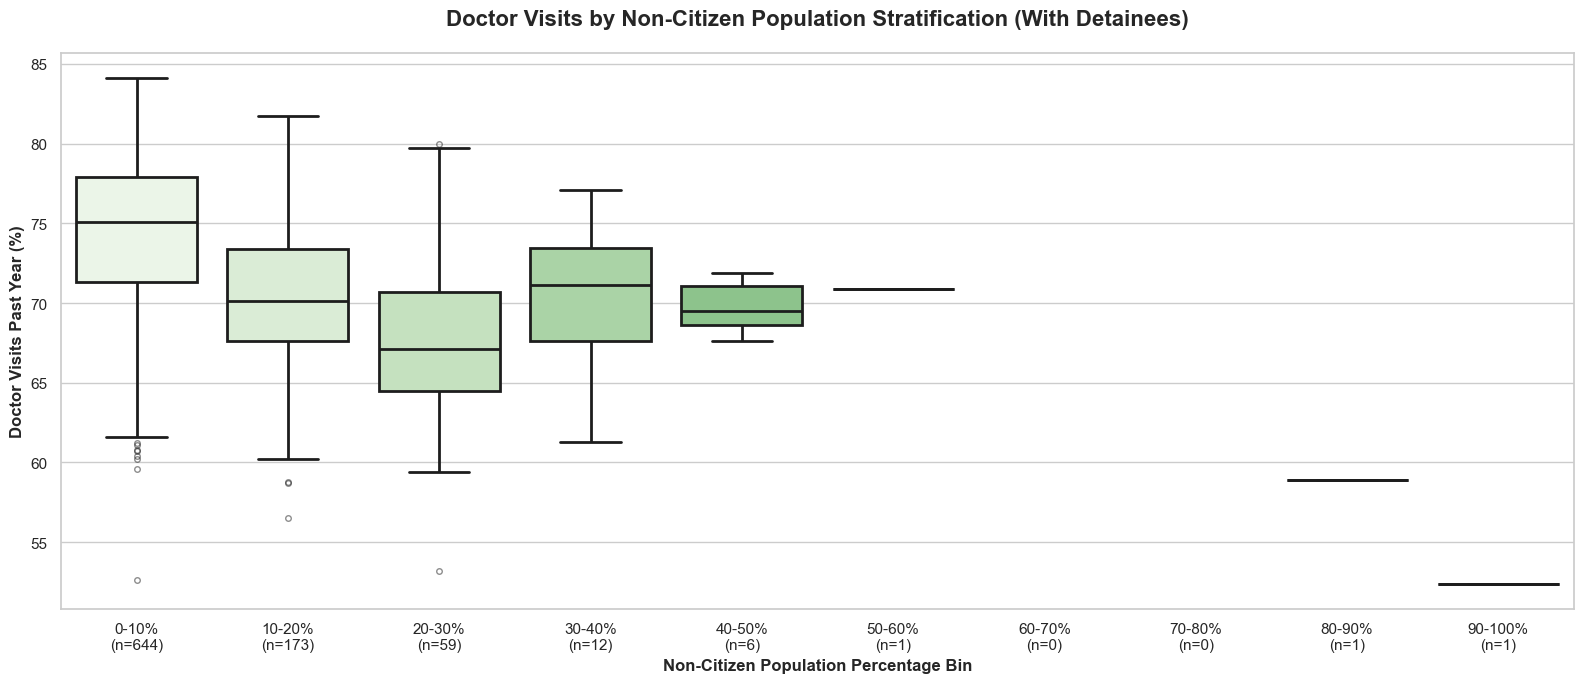

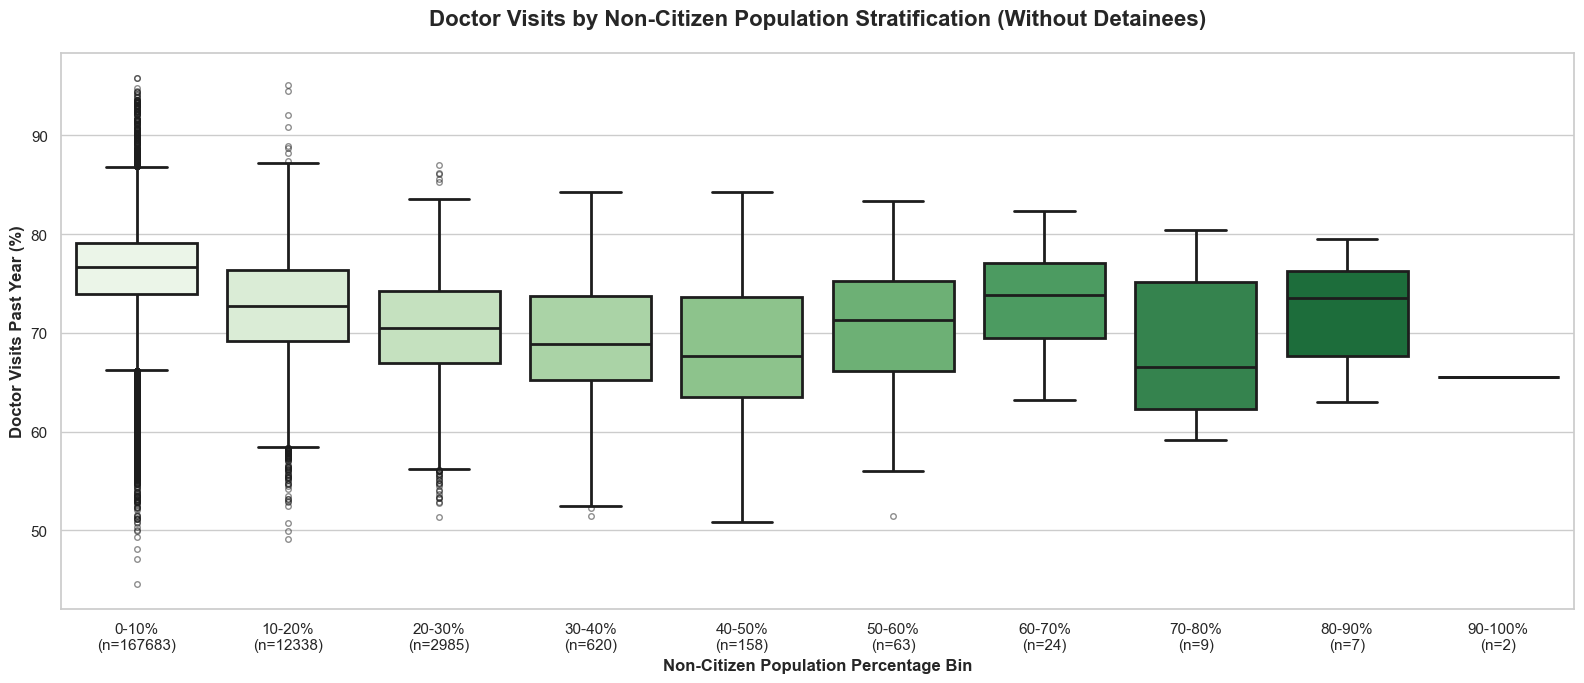

In [44]:
# Function to create stratified box plot for Non-Citizen Status
def create_citizen_stratified_boxplot(df, title_suffix):
    # Create citizen_strata with 10 bins
    df['citizen_strata'] = pd.cut(
        df['pct_non_citizen'],
        bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1],
        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
        right=False
    )
    
    # Set the theme for a clean look
    sns.set_theme(style="whitegrid")
    
    # Define the order for the x-axis categories
    strata_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
    
    # Create a single figure and axis
    plt.figure(figsize=(16, 7))
    
    # Create the boxplot on a single plane
    sns.boxplot(
        data=df,
        x='citizen_strata',
        y='doctor_visits_past_year',
        order=strata_labels,
        palette='Greens',      # Changed color to distinguish from the Hispanic plot
        linewidth=2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )
    
    # Add titles and labels
    plt.title(f'Doctor Visits by Non-Citizen Population Stratification ({title_suffix})', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Non-Citizen Population Percentage Bin', fontsize=12, fontweight='bold')
    plt.ylabel('Doctor Visits Past Year (%)', fontsize=12, fontweight='bold')
    
    # Add sample sizes (n=) to the x-tick labels for clarity
    counts = df['citizen_strata'].value_counts()
    new_labels = [f"{label}\n(n={counts.get(label, 0)})" for label in strata_labels]
    plt.xticks(ticks=range(len(strata_labels)), labels=new_labels)
    
    plt.tight_layout()
    plot_save_title = f"boxplot-dr-visits-by-citizen-status-{title_suffix.lower().replace(' ','-')}.png"
    plt.savefig(os.path.join(image_dir, plot_save_title), dpi=300, bbox_inches="tight")
    plt.show()

# Create plots for each dataset
create_citizen_stratified_boxplot(df_with_detainees, "With Detainees")
create_citizen_stratified_boxplot(df_without_detainees, "Without Detainees")

### Demographic Patterns in Care

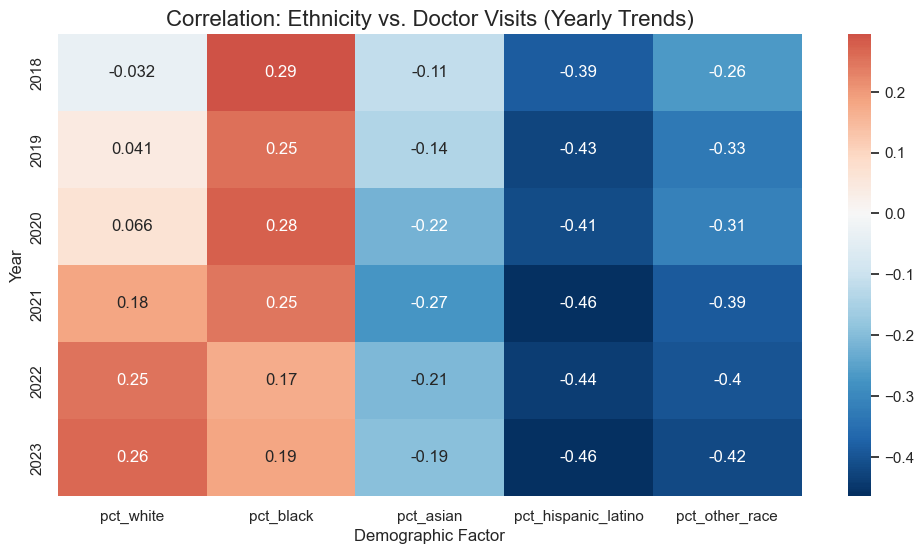

In [77]:
race_cols = ['pct_white', 'pct_black', 'pct_asian', 'pct_hispanic_latino', 'pct_other_race']
years = sorted(df_merged['year'].unique())
correlation_data = []

for yr in years:
    yearly_df = df_merged[df_merged['year'] == yr]
    corrs = yearly_df[race_cols + ['doctor_visits_past_year']].corr()['doctor_visits_past_year'].drop('doctor_visits_past_year')
    corrs.name = yr
    correlation_data.append(corrs)

# Combine into a single dataframe for heatmap
yearly_corr_df = pd.concat(correlation_data, axis=1).T

plt.figure(figsize=(12, 6))
sns.heatmap(yearly_corr_df, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation: Ethnicity vs. Doctor Visits (Yearly Trends)', fontsize=16)
plt.ylabel('Year')
plt.xlabel('Demographic Factor')
plt.savefig(os.path.join(image_dir, "corrplot-dr-visits-and-ethnicity.png"), dpi=300, bbox_inches="tight")
plt.show()

### Doctor Visits by Year

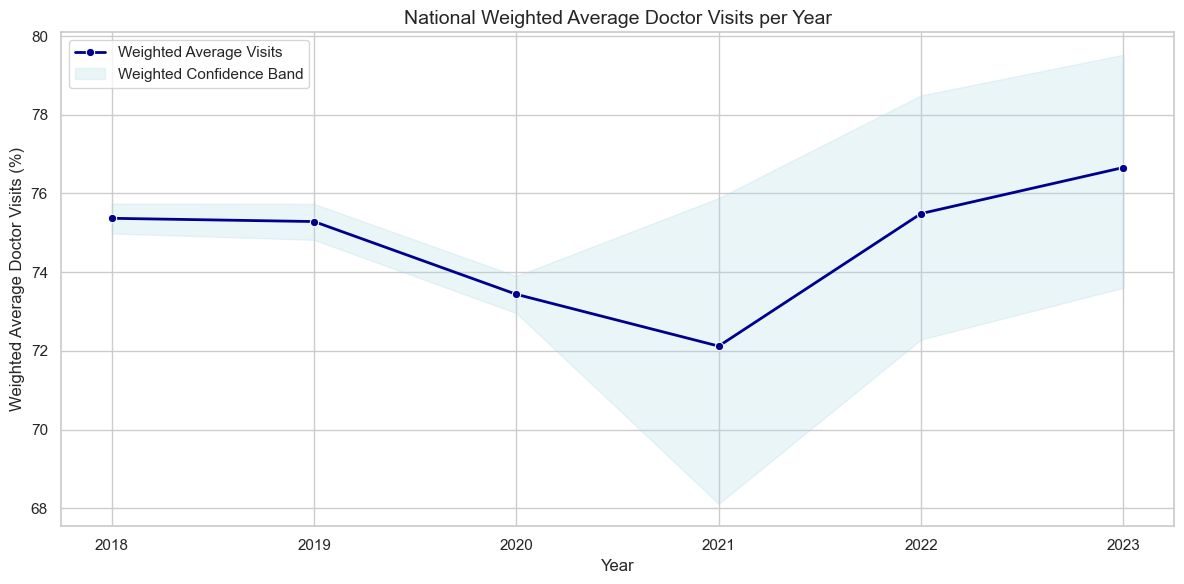

In [ ]:
# Convert percentage estimates into nominal counts using total population, then recompute the annual average.
df_merged['nominal_doctor_visits'] = df_merged['doctor_visits_past_year'] / 100 * df_merged['totalpopulation']
df_merged['nominal_low'] = df_merged['low_confidence_limit'] / 100 * df_merged['totalpopulation']
df_merged['nominal_high'] = df_merged['high_confidence_limit'] / 100 * df_merged['totalpopulation']

# Aggregate by year to compute the population-weighted average from nominal counts
df_yearly_weighted = (
    df_merged
    .groupby('year')
    .agg(
        total_population=('totalpopulation', 'sum'),
        total_visits=('nominal_doctor_visits', 'sum'),
        total_low=('nominal_low', 'sum'),
        total_high=('nominal_high', 'sum')
    )
    .reset_index()
)

df_yearly_weighted['weighted_avg'] = df_yearly_weighted['total_visits'] / df_yearly_weighted['total_population'] * 100
df_yearly_weighted['weighted_low'] = df_yearly_weighted['total_low'] / df_yearly_weighted['total_population'] * 100
df_yearly_weighted['weighted_high'] = df_yearly_weighted['total_high'] / df_yearly_weighted['total_population'] * 100

# Plot the annual weighted average with error bands
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_yearly_weighted,
    x='year',
    y='weighted_avg',
    marker='o',
    color='darkblue',
    linewidth=2,
    label='Weighted Average Visits'
)

plt.fill_between(
    df_yearly_weighted['year'],
    df_yearly_weighted['weighted_low'],
    df_yearly_weighted['weighted_high'],
    color='lightblue',
    alpha=0.25,
    label='Weighted Confidence Band'
)

# Formatting
plt.title('National Weighted Average Doctor Visits per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Average Doctor Visits (%)', fontsize=12)
plt.xticks(df_yearly_weighted['year'].unique())
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "lineplot-annual-dr-visits.png"), dpi=300, bbox_inches="tight")
plt.show()



### Doctor Visits by Economic Drivers 

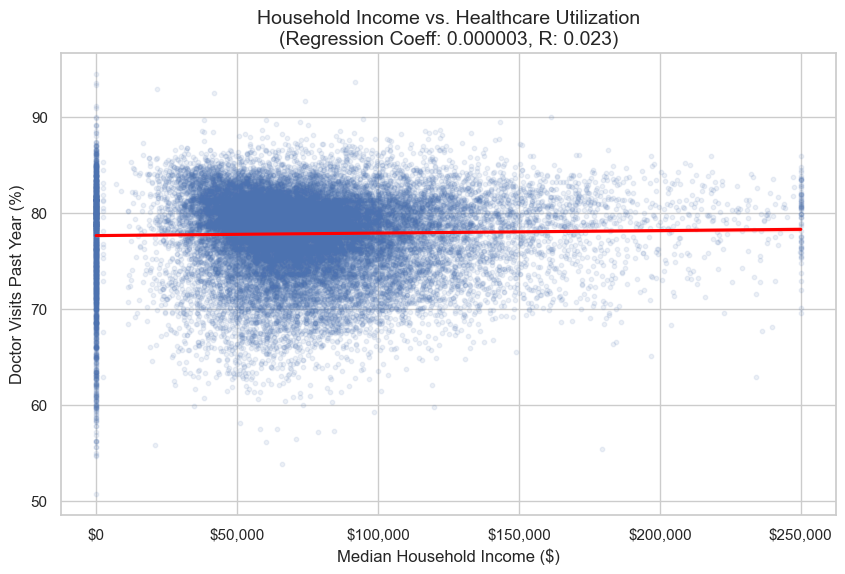

In [78]:
plt.figure(figsize=(10, 6))
# Calculate coefficient
mask = df_plot['median_household_income'].notna()
slope, intercept, r_val, p_val, std_err = stats.linregress(df_plot[mask]['median_household_income'], df_plot[mask]['doctor_visits_past_year'])

ax = sns.regplot(data=df_plot, x='median_household_income', y='doctor_visits_past_year', 
                 scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'red'})

# Formatting
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.title(f'Household Income vs. Healthcare Utilization\n(Regression Coeff: {slope:.6f}, R: {r_val:.3f})', fontsize=14)
plt.xlabel('Median Household Income ($)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-median-income.png"), dpi=300, bbox_inches="tight")
plt.show()

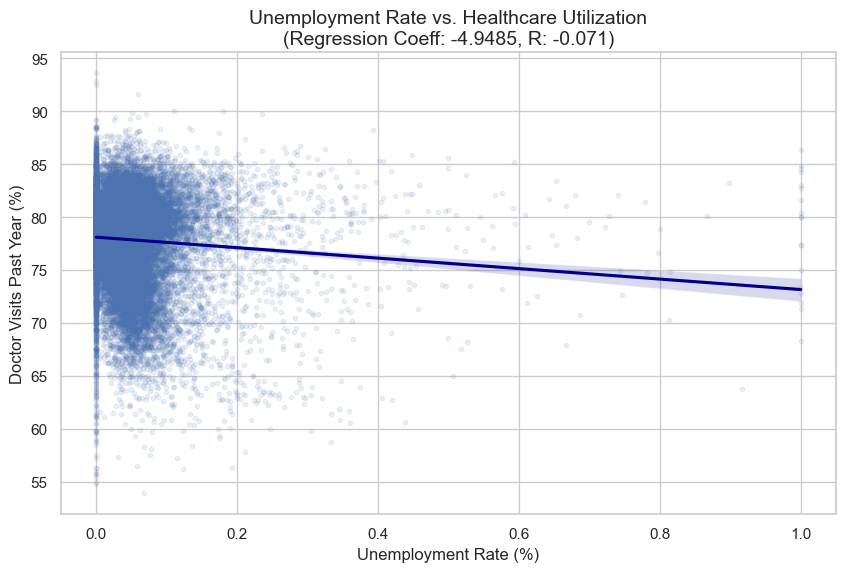

In [79]:
plt.figure(figsize=(10, 6))
# Calculate coefficient
mask = df_plot['pct_unemployed'].notna()
slope, intercept, r_val, p_val, std_err = stats.linregress(df_plot[mask]['pct_unemployed'], df_plot[mask]['doctor_visits_past_year'])

sns.regplot(data=df_plot, x='pct_unemployed', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'darkblue'})

plt.title(f'Unemployment Rate vs. Healthcare Utilization\n(Regression Coeff: {slope:.4f}, R: {r_val:.3f})', fontsize=14)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-enemployment-rate.png"), dpi=300, bbox_inches="tight")
plt.show()

### Impact of Educational Attainment on Doctor Visits

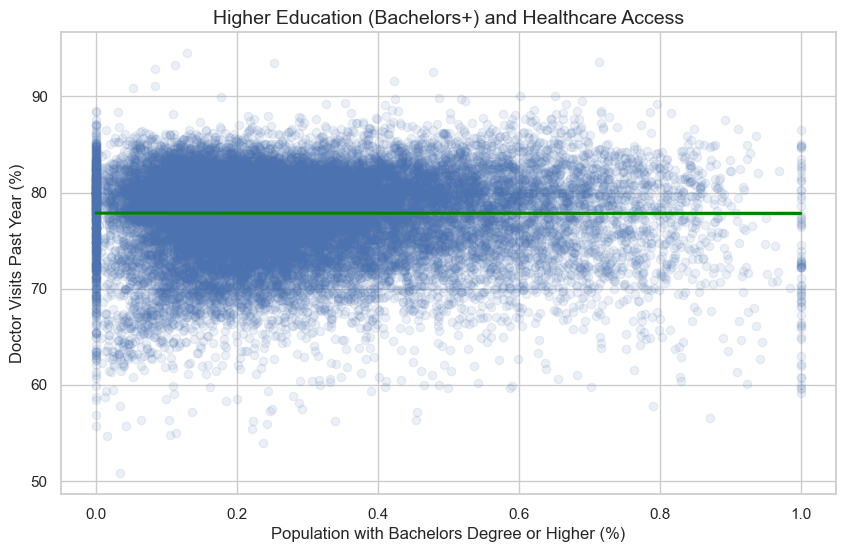

In [81]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='pct_bachelors_plus', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'green'})
plt.title('Higher Education (Bachelors+) and Healthcare Access', fontsize=14)
plt.xlabel('Population with Bachelors Degree or Higher (%)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-bach-rate"), dpi=300, bbox_inches="tight")
plt.show()

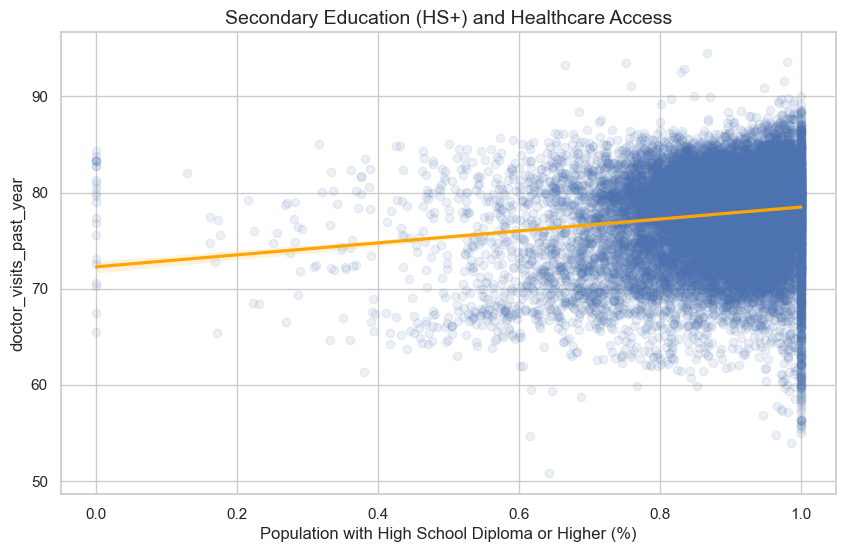

In [82]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='pct_high_school_or_higher', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'orange'})
plt.title('Secondary Education (HS+) and Healthcare Access', fontsize=14)
plt.xlabel('Population with High School Diploma or Higher (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-high-school-rate"), dpi=300, bbox_inches="tight")
plt.show()

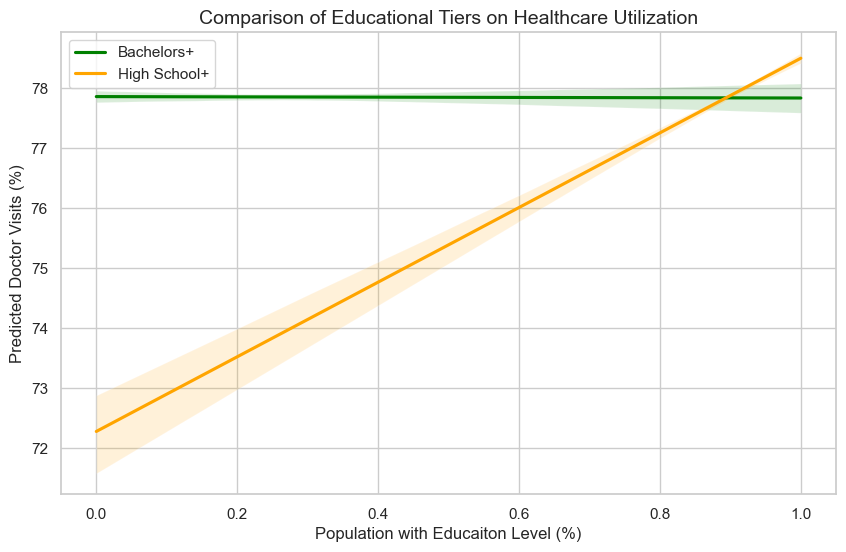

In [83]:
plt.figure(figsize=(10, 6))
# Plotting both lines without scatter to show the "slope" difference clearly
sns.regplot(data=df_plot, x='pct_bachelors_plus', y='doctor_visits_past_year', 
            scatter=False, label='Bachelors+', color='green')
sns.regplot(data=df_plot, x='pct_high_school_or_higher', y='doctor_visits_past_year', 
            scatter=False, label='High School+', color='orange')
plt.title('Comparison of Educational Tiers on Healthcare Utilization', fontsize=14)
plt.legend()
plt.ylabel('Predicted Doctor Visits (%)')
plt.xlabel('Population with Educaiton Level (%)')
plt.savefig(os.path.join(image_dir, "regressionplot-visits-vs-education.png"), dpi=300, bbox_inches="tight")
plt.show()

## Average Daily Detanees
### Detainees over the years

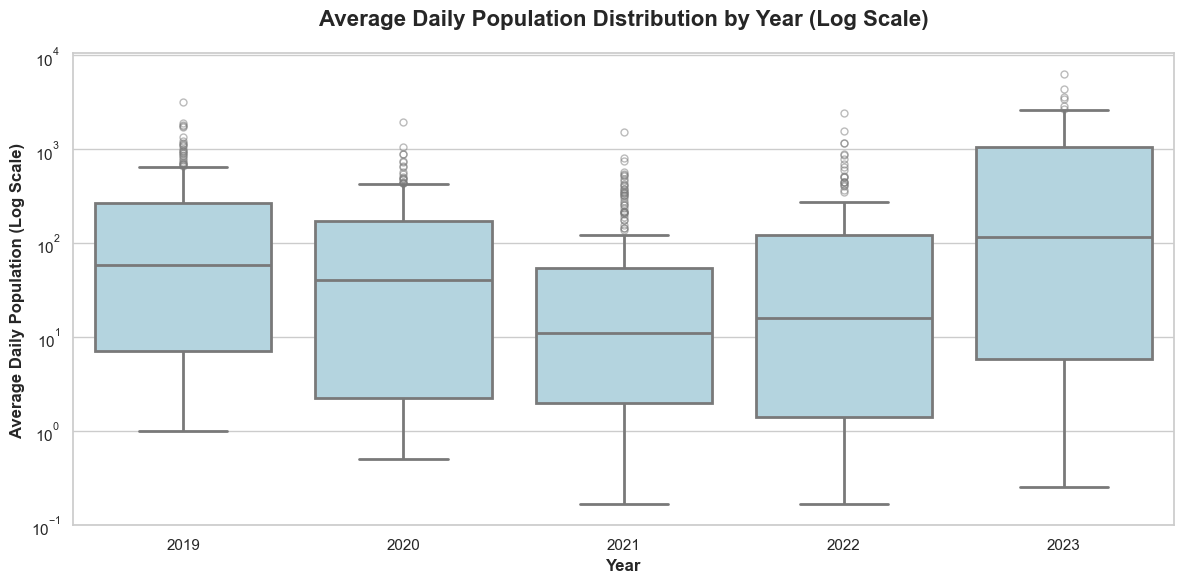

In [46]:
# Ensure we only have positive values for the log scale
detainee_df = df_merged[
    (df_merged['average_daily_population'] > 0) &
    (df_merged['average_daily_population'].notna())
].copy()

# Create a box and whisker plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=detainee_df,
    x='year',
    y='average_daily_population',
    color='lightblue',
    linewidth=2,
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.5}
)

# Apply logarithmic scale to the y-axis
plt.yscale('log')

# Update titles and labels to reflect the log scale
plt.title('Average Daily Population Distribution by Year (Log Scale)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Population (Log Scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "boxplot-avg-dly-pop-per-year.png"), dpi=300, bbox_inches="tight")
plt.show()

# Modeling

Analyze the relationship between immigration enforcement intensity and healthcare utilization.

## Model Specification

Define control variables and modeling approach.

In [ ]:
# Modeling approach:
# - Panel regression with fixed effects
# - Control variables: socioeconomic status, demographics, healthcare infrastructure
# - Dependent variable: Healthcare utilization (routine checkup rates)
# - Independent variable: Immigration enforcement intensity (detention counts)
# - Subgroup analysis by citizenship status and facility type

print("Model specification code will go here")

Model specification code will go here


## Model Estimation

Run regression models and generate results.

In [ ]:
# Convert to pandas for statsmodels
# panel_df = panel_data.toPandas()

# Fit regression model
# model = ols('healthcare_utilization ~ enforcement_intensity + controls', data=panel_df).fit()

# Display results
# print(model.summary())
k"), dpi=300, bbox_inches="tigh
print("Model estimation code will go here")

Model estimation code will go here


# Data Visualization

Create maps, scatter plots, and regression visualizations to illustrate findings.

## Geographic Distribution Maps (optional)

Create choropleth maps showing enforcement intensity and healthcare utilization across counties.

In [ ]:
# Create geographic visualizations
# - Map 1: Immigration enforcement intensity by county
# - Map 2: Healthcare utilization rates by county
# - Map 3: Combined visualization showing correlation

print("Geographic visualization code will go here")

Geographic visualization code will go here


## Scatter Plots and Regression Lines

Visualize the relationship between enforcement intensity and healthcare utilization.

In [ ]:
# Create scatter plots with regression lines
# - Overall relationship
# - By subgroups (citizenship status, facility type)
# - Time period comparisons

print("Scatter plot visualization code will go here")

Scatter plot visualization code will go here


## Time Series Analysis

Visualize trends in enforcement and healthcare utilization over time.

In [ ]:
# Create time series visualizations
# - Trends in ICE enforcement activity (2015-2025)
# - Trends in healthcare utilization rates
# - Key policy change periods (e.g., January 2025 sensitive location policy)

print("Time series visualization code will go here")

Time series visualization code will go here


# Results Summary

Summary of key findings and implications for the research article.

In [ ]:
# Key findings:
# 1. Geographic areas with high enforcement and low healthcare utilization
# 2. Statistical significance of the relationship
# 3. Subgroup differences
# 4. Policy implications

# Export results for inclusion in research article
print("Results summary and export code will go here")

# Note: This appendix supports the findings presented in:
# "Health Care Utilization and Immigration Enforcement" by Naomi Buell and Richie Rivera

Results summary and export code will go here
